# Cluster-ready forecasting demo

This notebook visualizes the current day-ahead forecasting evidence and shows how the household-level output will connect to the clustering team. It uses only checked-in real artifacts. **No cluster assignments are currently available, so no cluster results are invented.**

The default recipe is weather-free: persistence baselines and a global household-aware model are evaluated under the 00:00 UTC → 96 quarter-hour contract.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
ART = ROOT / "artifacts" / "model_ladder"
CONFIG = json.loads((ART / "model_config.json").read_text())
overall = pd.read_csv(ART / "overall_metrics.csv")
sliced = pd.read_csv(ART / "sliced_metrics.csv")
pred = pd.read_parquet(ART / "portfolio_predictions.parquet")
household = pd.read_parquet(ART / "household_metrics.parquet")
for col in ["origin", "target_timestamp"]:
    pred[col] = pd.to_datetime(pred[col], utc=True)

WINNER = CONFIG["selected_operational_model"]
sns.set_theme(style="whitegrid", context="notebook")
print(f"Loaded {len(pred):,} portfolio rows, {household.Household_ID.nunique()} household metric rows.")
print(f"Selected operational model: {WINNER}")

Loaded 202,752 portfolio rows, 139 household metric rows.
Selected operational model: daily_weekly_ensemble


In [2]:
# Fail early if the artifact contract changes unexpectedly.
required_prediction = {"model", "origin", "target_timestamp", "horizon_step", "actual", "prediction"}
required_metrics = {"model", "mae", "wape", "bias"}
assert required_prediction <= set(pred.columns)
assert required_metrics <= set(overall.columns)
assert pred.model.nunique() == len(overall)
assert pred.groupby("model").origin.nunique().nunique() == 1
assert CONFIG["forecast_spec"]["origin_hour"] == 0
assert CONFIG["forecast_spec"]["horizon"] == 96

summary = pd.DataFrame({"item": ["fit", "validation", "calibration", "test", "primary cohort", "execution mode"],
    "value": [f"{CONFIG['split_spec']['fit_start']} → {CONFIG['split_spec']['validation_start']}",
              f"{CONFIG['split_spec']['validation_start']} → {CONFIG['split_spec']['calibration_start']}",
              f"{CONFIG['split_spec']['calibration_start']} → {CONFIG['split_spec']['test_start']}",
              f"{CONFIG['split_spec']['test_start']} → {CONFIG['split_spec']['test_end']}",
              CONFIG["primary_cohort"]["size"], CONFIG["execution_mode"]]})
display(summary)

,item,value
0,fit,2022-02-28T00:00:00+00:00 → 2022-11-30T00:00:0...
1,validation,2022-11-30T00:00:00+00:00 → 2023-02-28T00:00:0...
2,calibration,2023-02-28T00:00:00+00:00 → 2023-05-29T00:00:0...
3,test,2023-05-29T00:00:00+00:00 → 2024-02-28T00:00:0...
4,primary cohort,139
5,execution mode,quick


## 1. Model comparison

MAE and WAPE are portfolio-level metrics on the common test rows. The oracle is shown for diagnosis only; it is not eligible for operational selection.

,model,mae,wape,bias,prediction_coverage,is_oracle,selected_on_validation
0,daily_weekly_ensemble,5.150,0.134,-0.126,0.96,False,True
1,previous_day,5.436,0.141,-0.082,0.96,False,False
7,lightgbm_oracle_bottom_up,6.460,0.167,-0.202,0.96,True,False
2,lightgbm_direct,6.464,0.168,-1.050,0.96,False,False
3,previous_week,7.836,0.203,-0.537,0.96,False,False
4,lightgbm_bottom_up,8.154,0.211,0.693,0.96,False,False
5,ridge_bottom_up,10.331,0.268,-0.557,0.96,False,False
6,historical_quarter_hour_mean,19.056,0.494,0.877,0.96,False,False


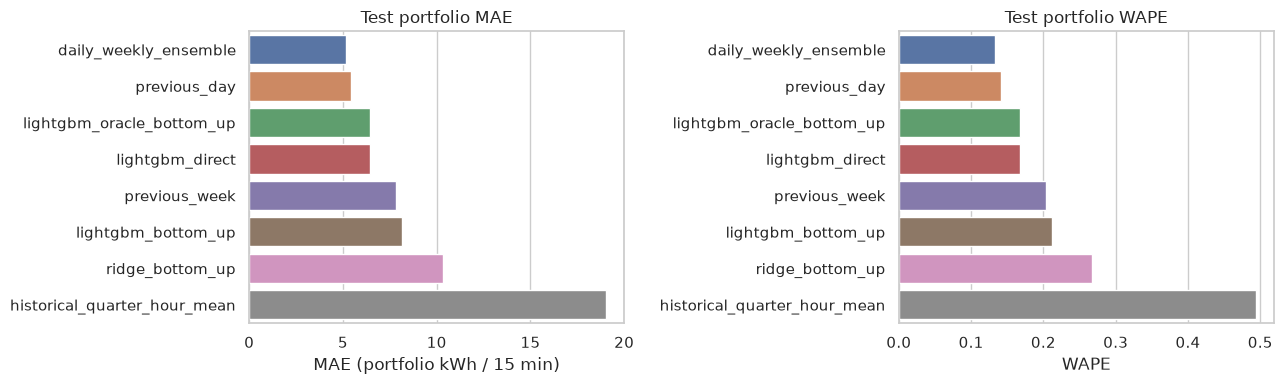

In [3]:
board = overall.sort_values("mae").copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=board, y="model", x="mae", hue="model", legend=False, palette="deep", ax=axes[0])
axes[0].set(title="Test portfolio MAE", xlabel="MAE (portfolio kWh / 15 min)", ylabel="")
sns.barplot(data=board, y="model", x="wape", hue="model", legend=False, palette="deep", ax=axes[1])
axes[1].set(title="Test portfolio WAPE", xlabel="WAPE", ylabel="")
plt.tight_layout()
display(board[["model", "mae", "wape", "bias", "prediction_coverage", "is_oracle", "selected_on_validation"]].round(3))

## 2. Where does the selected model make errors?

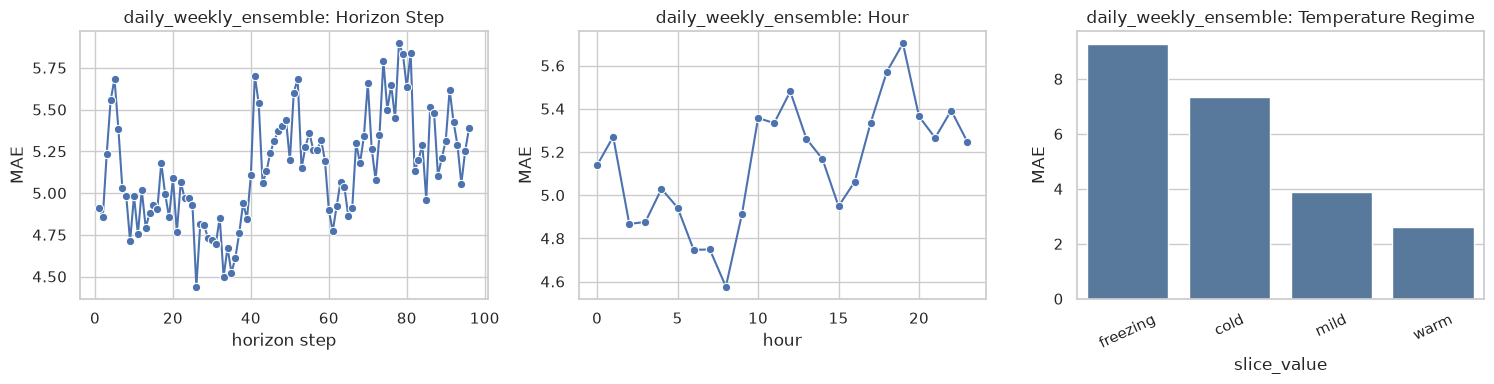

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, slice_name in zip(axes, ["horizon_step", "hour", "temperature_regime"]):
    part = sliced[(sliced.model == WINNER) & (sliced.slice == slice_name)].copy()
    if part.empty:
        ax.set_visible(False); continue
    if slice_name in {"horizon_step", "hour"}:
        part["slice_value"] = pd.to_numeric(part["slice_value"])
        sns.lineplot(data=part, x="slice_value", y="mae", marker="o", ax=ax)
        ax.set_xlabel(slice_name.replace("_", " "))
    else:
        sns.barplot(data=part, x="slice_value", y="mae", color="#4c78a8", ax=ax)
        ax.tick_params(axis="x", rotation=25)
    ax.set_title(f"{WINNER}: {slice_name.replace('_', ' ').title()}")
    ax.set_ylabel("MAE")
plt.tight_layout()

## 3. Example day-ahead forecast

The selected model produces a complete 96-step day-ahead profile at each origin. This plot uses the test origin whose mean absolute error is closest to the median.

Example-origin MAE: 3.89 kWh


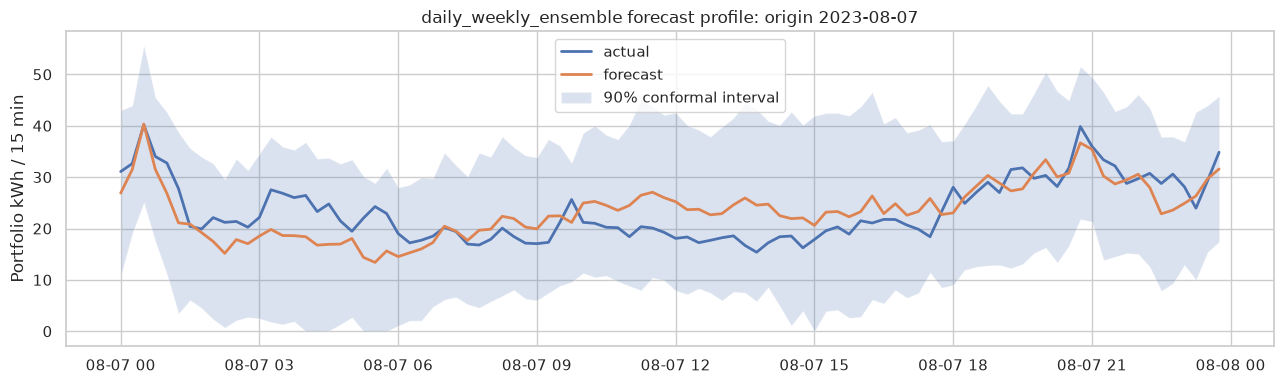

In [5]:
winner_pred = pred[pred.model == WINNER].copy()
day_scores = winner_pred.groupby("origin").apply(lambda x: np.mean(np.abs(x.actual - x.prediction)), include_groups=False)
example_origin = day_scores.index[np.argmin(np.abs(day_scores.to_numpy() - day_scores.median()))]
example = winner_pred[winner_pred.origin == example_origin].sort_values("target_timestamp")
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(example.target_timestamp, example.actual, label="actual", linewidth=2)
ax.plot(example.target_timestamp, example.prediction, label="forecast", linewidth=2)
if example.lower.notna().any():
    ax.fill_between(example.target_timestamp, example.lower, example.upper, alpha=.2, label="90% conformal interval")
ax.set(title=f"{WINNER} forecast profile: origin {example_origin.date()}", ylabel="Portfolio kWh / 15 min")
ax.legend(); plt.tight_layout()
print(f"Example-origin MAE: {day_scores.loc[example_origin]:.2f} kWh")

## 4. Household heterogeneity

The global model is evaluated at portfolio level for procurement, but household-level errors remain important for deciding whether future cluster-specific models are worthwhile.

,Household_ID,PV_Status,mae,wape,bias
171,1111201,true,0.517,0.718,-0.164
182,116121,false,0.483,0.595,-0.275
267,8701118,unknown,0.435,0.405,-0.292
174,112122,true,0.415,0.743,-0.186
246,7771161,false,0.403,0.627,-0.246
216,669010,false,0.370,0.471,-0.227
150,1037610,false,0.341,0.618,-0.146
276,991118,false,0.333,0.715,-0.110
179,1148611,true,0.329,0.861,-0.081
224,7011879,unknown,0.326,0.874,-0.076


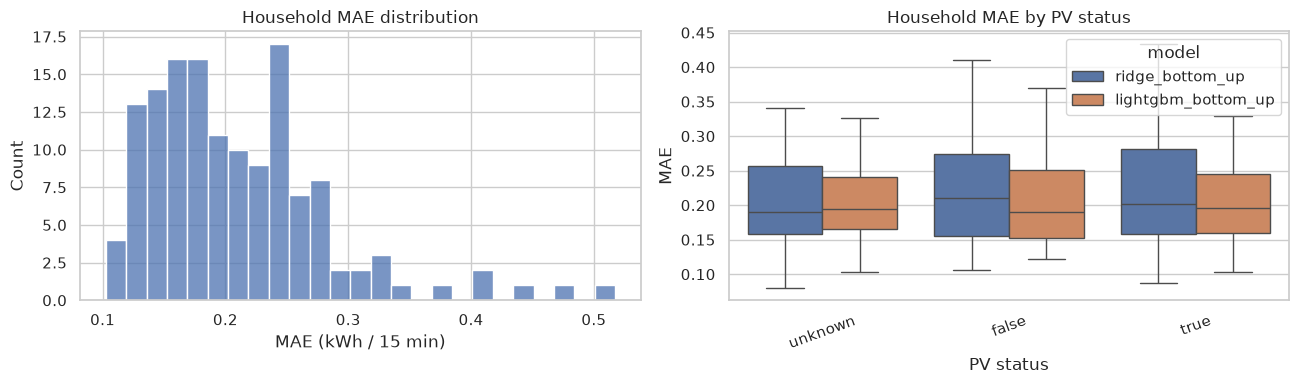

In [6]:
hm = household[household.model == "lightgbm_bottom_up"].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(hm.mae, bins=25, ax=axes[0])
axes[0].set(title="Household MAE distribution", xlabel="MAE (kWh / 15 min)")
sns.boxplot(data=household, x="PV_Status", y="mae", hue="model", showfliers=False, ax=axes[1])
axes[1].set(title="Household MAE by PV status", xlabel="PV status", ylabel="MAE")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
display(hm.nlargest(10, "mae")[["Household_ID", "PV_Status", "mae", "wape", "bias"]].round(3))

## 5. Uncertainty and coverage

Mean interval width: 31.1 portfolio kWh


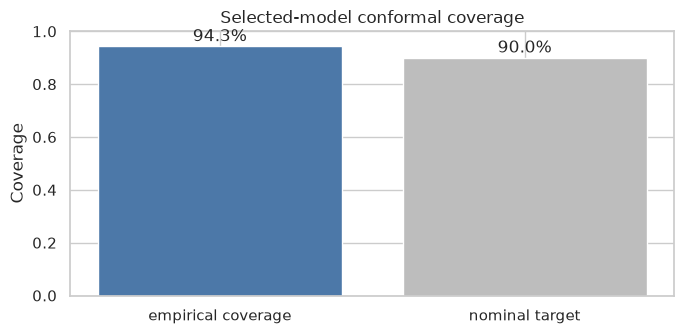

In [7]:
winner_row = overall.loc[overall.model == WINNER].iloc[0]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(["empirical coverage", "nominal target"], [winner_row.interval_coverage, .90], color=["#4c78a8", "#bdbdbd"])
ax.set_ylim(0, 1); ax.set_ylabel("Coverage"); ax.set_title("Selected-model conformal coverage")
for i, value in enumerate([winner_row.interval_coverage, .90]): ax.text(i, value + .02, f"{value:.1%}", ha="center")
plt.tight_layout()
print(f"Mean interval width: {winner_row.mean_interval_width:.1f} portfolio kWh")

## 6. Cluster integration status

The new utilities are ready for a real static table with one row per household:

```text
Household_ID,cluster_id
1001188,cluster_a
...
```

This notebook intentionally does not create assignments. Once the clustering team supplies them, pass the household-level predictions and labels to `aggregate_clusters`, and use `cluster_model_plan` to decide which clusters have enough data for local fitting.

In [8]:
from utils.modeling import aggregate_clusters, cluster_model_plan, validate_cluster_labels

cluster_label_path = ROOT / "artifacts" / "clusters" / "household_clusters.csv"
if cluster_label_path.exists():
    cluster_labels = pd.read_csv(cluster_label_path)
    cluster_labels = validate_cluster_labels(cluster_labels, household_ids=hm.Household_ID.unique())
    print(f"Loaded {cluster_labels.cluster_id.nunique()} real clusters.")
    print("Cluster aggregation is ready; model-specific cluster fitting must still be evaluated on validation origins.")
else:
    print("STATUS: real cluster labels are not available yet; cluster metrics are intentionally not produced.")
    print(f"Expected file: {cluster_label_path}")

STATUS: real cluster labels are not available yet; cluster metrics are intentionally not produced.
Expected file: /home/nicolas.avila/dev/rwth_hackathon/artifacts/clusters/household_clusters.csv


## Decision and next steps

- Keep the daily/weekly persistence ensemble as the current operational benchmark.
- Use the global household-aware model as the cluster-agnostic training recipe.
- When real cluster labels arrive, compare global, cluster-conditioned, and thresholded per-cluster models on the same rolling origins.
- Keep weather optional; do not make it a production dependency until fair forecast-weather evidence shows value.
- Run the full 400-tree/all-origin configuration before deployment claims.